In [3]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import RNA
from scipy.special import gammaln

In [4]:
pop1 = '80'
reg_weight_str = 'main'
path_exp_mut_data ="/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/designed_sequence/outputs/synthetic_bistable_" + reg_weight_str + "/synthetic_bistable_" + pop1 + "/detailed/data/bistable_synthetic_"+pop1+"_50mM_r0.csv"
eps_path = "/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/designed_sequence/outputs/synthetic_bistable_" + reg_weight_str + "/synthetic_bistable_" + pop1 + "/detailed/bistable_synthetic_"+pop1+"_eps_b.npy"
path_phys_params = "/home/mauro-maglione/Documents/MERGE-RNA/fits_paper/designed_sequence/outputs/synthetic_bistable_" + reg_weight_str + "/synthetic_bistable_" + pop1 + "/params1D.txt"

In [5]:
df_mutations = pd.read_csv(path_exp_mut_data)

sequence = df_mutations.ref_nt.values
mutation_counts = df_mutations.mut_count.values
coverage_per_site = df_mutations.total_count.values

print(sequence)

['U' 'A' 'A' 'U' 'A' 'C' 'G' 'A' 'C' 'U' 'C' 'A' 'C' 'U' 'A' 'U' 'A' 'G'
 'G' 'G' 'C' 'A' 'U' 'U' 'A' 'U' 'G' 'C' 'C' 'A' 'C' 'A' 'G' 'C' 'C' 'A'
 'A' 'U' 'C' 'C' 'C' 'C' 'A' 'C' 'U' 'U' 'C' 'A' 'A' 'C' 'U' 'C' 'A' 'C'
 'A' 'A' 'C' 'U' 'A' 'U' 'U' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A' 'U' 'U' 'G'
 'G' 'A' 'A' 'U' 'A' 'G' 'U' 'U' 'G' 'U' 'G' 'A' 'G' 'U' 'U' 'G' 'A' 'A'
 'G' 'U' 'G' 'G' 'G' 'G' 'A' 'U' 'U' 'A' 'A' 'A' 'A' 'A' 'A' 'U' 'C' 'C'
 'C' 'C' 'A' 'C' 'U' 'U' 'C' 'A' 'A' 'C' 'U' 'C' 'A' 'C' 'A' 'A' 'C' 'U'
 'A' 'U' 'U' 'C' 'C' 'A' 'A' 'C' 'C' 'U' 'C' 'C' 'A' 'G' 'C' 'A' 'G' 'A'
 'C' 'C' 'A' 'U']


In [6]:
seq = "".join(sequence)
fc=RNA.fold_compound(seq)
fc.pf()
bpp=fc.bpp()
bpp = np.array(fc.bpp())[1:,1:]
bpp+=bpp.T
bpp=np.sum(bpp,axis=0)

In [7]:
phys_const_from_fit_metadata = {"temp_C": 37, "conc_mM": 50}

### Compute parameters of the "mutation probability" from merge_rna output data
No explicit expression of the parameters needs to be written

First we copied (and slightly modified) help functions for handling physical parameters from files and for paching them in the format needed. Consider that also the temp and conc need to be retrieved (non fitted physical parameters), for now I do it manually since they are only two

In [8]:
def convert_p_bind_1d_to_dict(p_bind_1d, DMS_mode=True):
    '''Convert the 1D array of p_bind to a dictionary.
    If DMS_mode is True, input is a 4-element array and will put 0A, 0C to 0 and 1G, 1U to equal to  0G, 0U.'''
    list_partial_keys = ["p_bind_A_", "p_bind_C_", "p_bind_G_", "p_bind_U_"]
    if DMS_mode:
        p_bind_dict = {incom_key+"0": value for incom_key, value in zip(list_partial_keys, p_bind_1d)}
        p_bind_dict["p_bind_A_"+"1"] = 0
        p_bind_dict["p_bind_C_"+"1"] = 0
        p_bind_dict["p_bind_G_"+"1"] = p_bind_dict["p_bind_G_"+"0"]
        p_bind_dict["p_bind_U_"+"1"] = p_bind_dict["p_bind_U_"+"0"]
    else:
        list_keys = []

        for str in ["0", "1"]:
            list_keys.append(str.join(list_partial_keys))

        p_bind_dict = {key: value for key, value in zip(list_keys, p_bind_1d)}
    return p_bind_dict

In [9]:
def pack_params(params_1d, dict_with_phys_params_pos):
    '''Unpacks the 1D array of parameters into a dictionary.'''
    params = {}
    for param, pos in dict_with_phys_params_pos.items():
        params[param] = params_1d[pos]
    # Convert the 1D array for p_bind into a dictionary.
    p_bind_dict = convert_p_bind_1d_to_dict(params['p_bind'])
    # maybe I will implement the test later
    return params

In [10]:
def _generate_phys_params_positions(DMS_mode=True):
    '''Generate parameter positions mapping'''
    base_config = {
        'mu_r': 0,
        'p_b': 1,
        'p_bind': list(range(2, 10 if not DMS_mode else 6)),
        'm0': 10 if not DMS_mode else 6,
        'm1': 11 if not DMS_mode else 7,
    }
    params_pos = base_config.copy()
    return params_pos

In [11]:
pos_dict = _generate_phys_params_positions()
print(pos_dict)

{'mu_r': 0, 'p_b': 1, 'p_bind': [2, 3, 4, 5], 'm0': 6, 'm1': 7}


In [12]:
vec_phys_params = np.loadtxt(path_phys_params)

phys_params_dict = pack_params(vec_phys_params,pos_dict)
print(phys_params_dict)

{'mu_r': np.float64(0.40456049704138497), 'p_b': np.float64(0.14104732947920853), 'p_bind': array([0.36251399, 0.23412978, 0.06800555, 0.00203605]), 'm0': np.float64(0.001065791888193865), 'm1': np.float64(0.6852534778035398)}


In [13]:
# The eps are fitted physical parameters
eps_vec = np.load(eps_path, mmap_mode=None, allow_pickle=False, fix_imports=True, encoding='ASCII')
print(eps_vec)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


Now I write a function that uses the same machinery used in merge rna to compute the average probability of mutation,
$$
\langle M_i \rangle = a_i+b_i\, \langle s_i \rangle
$$
but it runs it with pairing probs equal to $0$ and $1$. \
I write the function in order to give the coefficients of the mutation rate in the form:
$ M_i = a_i+b_i\,s_i $
, but maybe it could be better to use an expression $ M_i = 1-a'_i+(a'_i-b'_i)s_i $  to neglect some cancellation that happens in $b_i$ where there is a difference between two close numbers. \
The two close numbers are 
$$
\frac{e^{\beta \, \mu}}{1+ e^{\beta \, \mu}} \qquad \frac{e^{\beta \, (\mu - \Delta \mu)}}{1+ e^{\beta \, (\mu - \Delta \mu)}}
$$
When the nucleotides are U or G, since in their case the p_bind is independent of the contact state of the nucleotide

In [14]:
def mut_prob_condit_contact_merge_rna(seq,eps_b,*,
                            conc_mM,temp_C,
                            #p_bind_A_0, p_bind_A_1, p_bind_U_0, p_bind_U_1, p_bind_C_0, p_bind_C_1,p_bind_G_0, p_bind_G_1,
                            p_bind,
                            mu_r, p_b, m0, m1):
    
    kBT = (273.15 + temp_C) * (1.98717/1000) # kcal/mol, matches fit.py's self.kBT = self.temp_K * kb
    beta = 1/kBT
    mu_j = mu_r + kBT * np.log((conc_mM+.1)/1000) if conc_mM is not None else mu_r
    f_mu = np.exp(beta*mu_j)/(1-np.exp(beta*mu_j))
    f_mu_prime = np.exp(beta*(mu_j-p_b))/(1-np.exp(beta*(mu_j-p_b)))

    dict_pbind = convert_p_bind_1d_to_dict(p_bind) 

    def compute_penalty_m(mu, p_b_):
        '''Compute the penalty for paired bases in kcal/mol'''
        mu_prime = mu-p_b_
        penalty_in_kbt = -math.log((1+math.exp(beta*mu_prime))/(1+math.exp(beta*mu)))
        penalty_in_kcal_per_mol = penalty_in_kbt * kBT #TBC: to be checked
        return penalty_in_kcal_per_mol

    def compute_mu_dependent_quantities(mu, p_b_):
        '''Returns some key quantities that depend on mu: e^beta*mu, e^beta*mu', p(c_b|s_b,n_b)'''
        mu_prime = mu - p_b_
        e_beta_mu = math.exp(beta*mu)
        e_beta_mu_prime = math.exp(beta*mu_prime)
        e_beta_mu_norm = e_beta_mu / (1 + e_beta_mu)
        e_beta_mu_prime_norm = e_beta_mu_prime / (1 + e_beta_mu_prime)
        # probability of chemical binding
        p_cb_given_sb_nb = dict() # p(cb=1|s_b,n_b) -> p_cb[(s_b,n_b)] , cb = 1 is implicit.
        for s_b in [0, 1]:
            physical_binding_probability = e_beta_mu_norm if s_b == 0 else e_beta_mu_prime_norm
            for n_b in ['A', 'C', 'G', 'U']:
                p_cb_given_sb_nb[(s_b, n_b)] = dict_pbind["p_bind_"+n_b+"_"+str(s_b)] * physical_binding_probability # p(cb=0|s_b,n_b) = 1 - p(cb=1|s_b,n_b)
        return e_beta_mu, e_beta_mu_prime, p_cb_given_sb_nb

    def compute_p_cb(mu, p_b_, pairing_probs):
        '''Compute p(c_b) for the whole sequence'''
        # compute mu dependent quantities (and p(c_b|s_b,n_b))
        _, _, p_cb_given_sb_nb = compute_mu_dependent_quantities(mu, p_b_)
        # apply penalty for paired bases
        penalty = compute_penalty_m(mu, p_b_)
        # compute p(s_b)
        try:
            assert 0 <= penalty <= 5
        except AssertionError:
            print('Warning, penalty is not in [0,5]')
            print(f'penalty: {penalty}, mu: {mu}, p_b: {p_b}')
        # compute p(c_b)
        p_cb = np.zeros(len(seq))
        for i,nb in enumerate(seq):    # weighted sum over s_b=0,1
            p_cb[i] = p_cb_given_sb_nb[(1, nb)]*pairing_probs[i] + p_cb_given_sb_nb[(0, nb)]*(1-pairing_probs[i])
        return p_cb

    # 2a: mutation profile model
    def compute_mutation_profile(m0, m1,eps_b, p_cb):
        '''Compute the mutation profile predicted by the model with the current parameters.
        Later: compute its derivatives'''
        # compute mutation profile
        Mb = 1 - np.exp(-eps_b) * (math.exp(-m0) +  p_cb*(math.exp(-m1) - math.exp(-m0)))
        return Mb
    
    a_merge = compute_mutation_profile(m0, m1, eps_b, compute_p_cb(mu_j, p_b, np.zeros(len(seq))))
    a_plus_b_merge = compute_mutation_profile(m0, m1, eps_b, compute_p_cb(mu_j, p_b, np.ones(len(seq))))
    return a_merge, a_plus_b_merge-a_merge

In [15]:
a_from_merge, b_from_merge = mut_prob_condit_contact_merge_rna(sequence, eps_vec, **phys_const_from_fit_metadata, **phys_params_dict)

Then I take the expressions from Giovanni's notes on the approximation of the likelihood function
$$
    S^{\text{exp}}_i = \frac{z_i-T_i\, a_i}{T_i \, b_i} \qquad \frac{1}{\sigma_i^2}= \frac{b_i^2\, T_i^3}{(T_i-z_i)z_i}
$$
where $z_i$ is the mutation count, $T_i$ is the coverage at site i. \
In particular $S^{\text{exp}}_i$ would be the value of the pairing probability that would give the experimental mutation counts observed, for given $a_i$ e $b_i$.

In [16]:
def compute_expansion_parameters(z, T, a, b):
    target_contact_prob = (z-T*a)/(T*b)
    squared_confidence_interval = ((T - z) / T) * (z / T**2) / b**2 #this is the inverse of the equation
    return target_contact_prob, squared_confidence_interval

In [17]:
target_contact_prob, squared_confidence_interval = compute_expansion_parameters(mutation_counts, coverage_per_site, a_from_merge, b_from_merge)

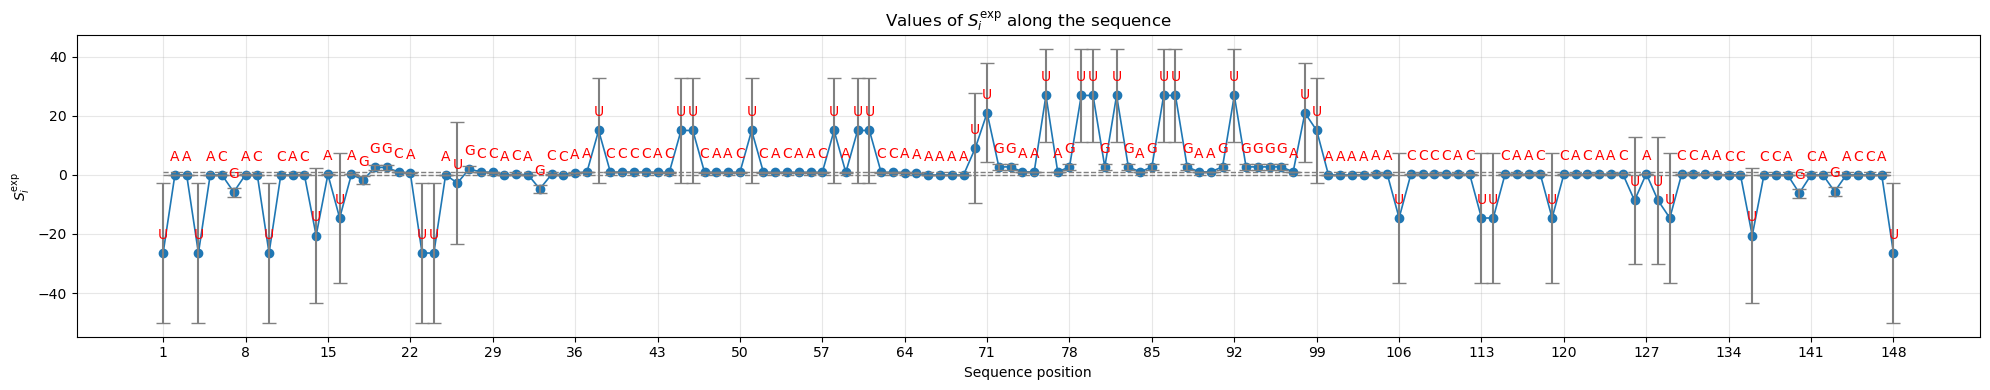

In [28]:
# positions along the sequence
positions = np.arange(1, len(sequence) + 1)

# b_from_fit is the array you already computed
y = target_contact_prob
y_errors = np.sqrt(squared_confidence_interval)

fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(positions, y, marker='o', linestyle='-', linewidth=1.2, color='tab:blue')
ax.errorbar(positions, y, yerr=y_errors, ecolor='gray', fmt='none', capsize=5)

# add nucleotide letters near each point
for x, yy, nt in zip(positions, y, sequence):
    ax.annotate(
        nt,
        xy=(x, yy),
        xytext=(0, 8),           # offset upward
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color="red"
    )

ax.set_xticks(positions[::7])

ax.hlines(y=0, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)
ax.hlines(y=1, xmin=1, xmax=len(sequence), colors='gray', linestyles='dashed', linewidth=1)

ax.set_xlabel("Sequence position")
ax.set_ylabel(r"$S^{\text{exp}}_i$")
ax.set_title(r"Values of $S^{\text{exp}}_i$ along the sequence")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Some $S_i^{\text{exp}}$ sono non fisici, principalmente quelli per i nucleotidi U, G che sono poco informativi (questo è legato a quello che si diceva prima del piccolo valore di b_i) (questo è vero per i dati puramente sintetici, da verificare con dati sperimentali reali). \
This could maybe be improved by using data that actually sampled from  a binomial. \
I think that a big role is played by the fact that the eps are 0 and by the fact that the physical parameters are fitted globally.

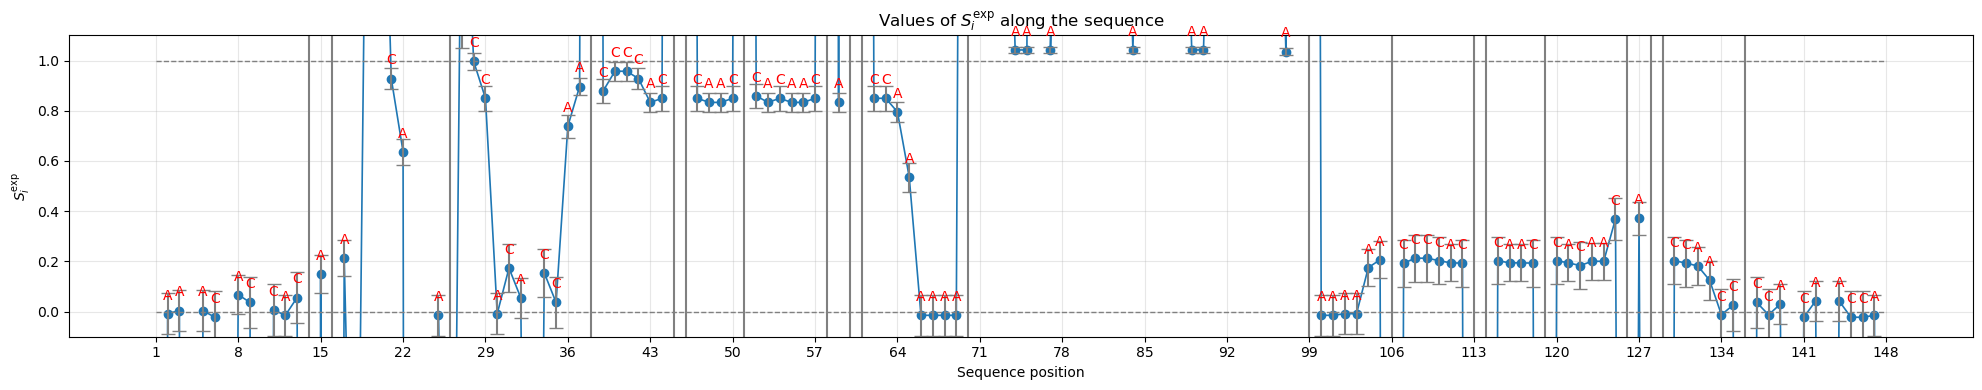

In [ ]:
ax.set_ylim(-0.1, 1.1)  # Set y-axis limits to show the S_i in the physical range
#plt.draw() seems to not work
fig.canvas.draw_idle()
fig